In [6]:
%autoreload 2

In [28]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import gridspec, rcParams
from datetime import datetime as dt, timedelta
import pingouin as pg
import scipy.stats as stats
from fish import Gafftopsail
sys.path.append(r'/Users/zichenhe/miniforge3/envs/naumann_lab/2ptank/')#(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = ('C:/Data/Imaging/260425_overlap/fish9//')
rcParams['font.size'] = 4

In [29]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging'], sequence = 5)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]
f_pertrial_dict = barcode.get_pertrial_f(fish)

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s


__barcoding 1: large response__

In [40]:
barred_dotneurons= pd.read_csv(fish.path + '//analyze_results//dot_responses.csv', index_col = 0)
barred_gratingneurons = pd.read_csv(fish.path + '//analyze_results//grating_responses.csv', index_col = 0)
#change them to dictionary
dot_stims = ['dot_l', 'dot_r']
grating_stims = ['forward', 'left', 'right', 'backward']
barred_dotneurons = {s: list(barred_dotneurons[barred_dotneurons['barred_' + s]].index) for s in dot_stims}
barred_gratingneurons = {s: list(barred_gratingneurons[barred_gratingneurons['barred_' + s]].index) for s in grating_stims}


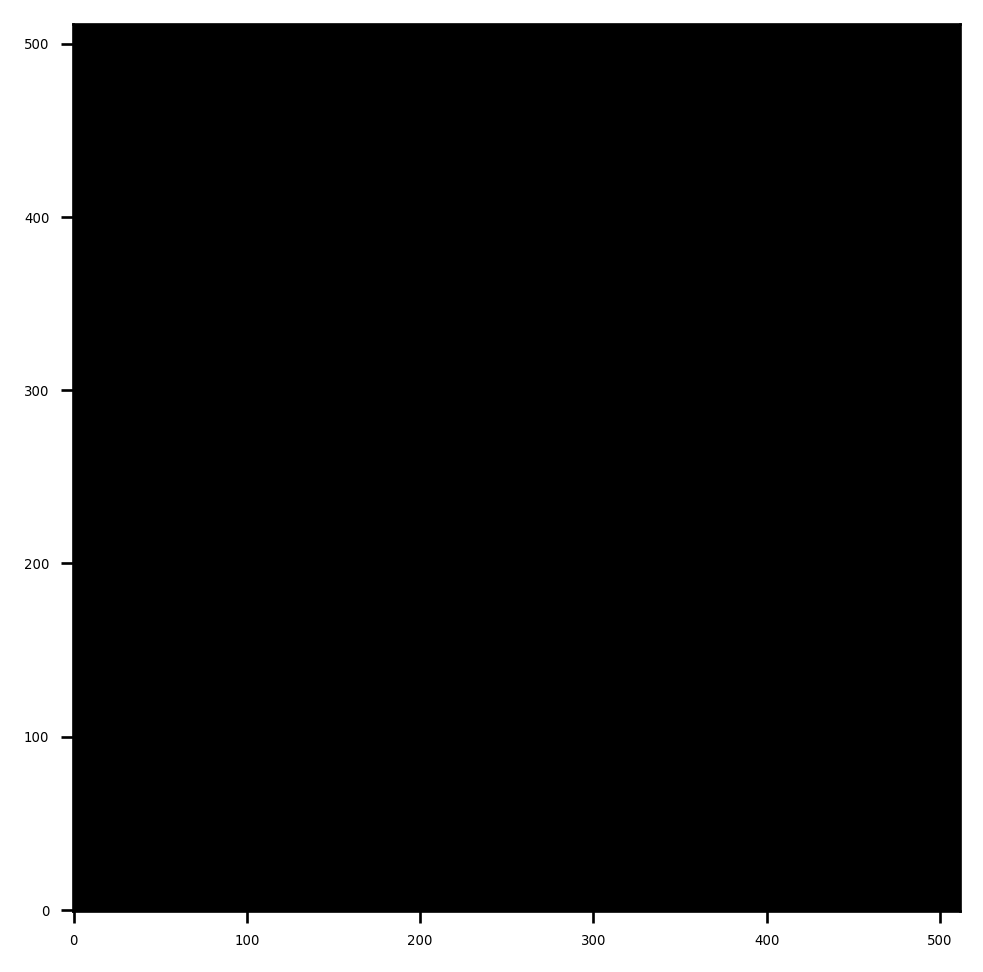

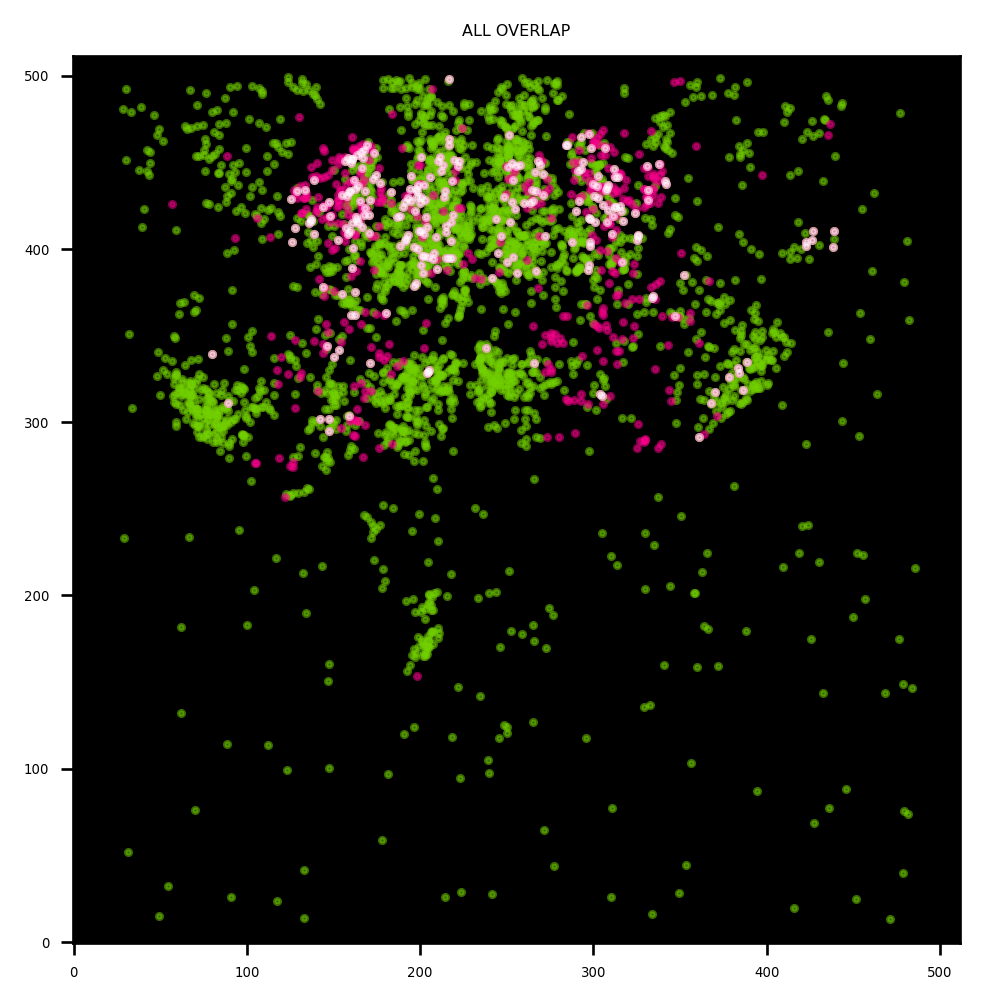

In [41]:
#plot all neurons overlap
def plot_sharedcells(fish, barred_gratingneurons, barred_dotneurons):
    pink = "#FB008C"
    green = "#72D100"
    fig, ax = plt.subplots(1, 1, dpi = 240)
    omr_sets = [set(barred_gratingneurons[s]) for s in barred_gratingneurons.keys()]
    omr_sets = set.union(*omr_sets)
    dot_sets = [set(barred_dotneurons[s]) for s in barred_dotneurons.keys()]
    dot_sets = set.union(*dot_sets)
    overlap_sets =  list(omr_sets & dot_sets)
    ax.imshow(fish.img_dict[3], cmap='Greys_r', origin='lower',vmin = 299, vmax=300)
    ax.scatter(fish.pos_all.loc[list(omr_sets), 'xpos'], fish.pos_all.loc[list(omr_sets), 'ypos'],
            s=3, facecolor=green, alpha=0.5)
    ax.scatter(fish.pos_all.loc[list(dot_sets), 'xpos'], fish.pos_all.loc[list(dot_sets), 'ypos'],
            s=3, facecolor=pink, alpha=0.5)
    ax.scatter(fish.pos_all.loc[overlap_sets, 'xpos'], fish.pos_all.loc[overlap_sets, 'ypos'],
            s=3, facecolor='white', alpha=0.5)
    ax.set_title('ALL OVERLAP')
    return fig
fig = plot_sharedcells(fish, barred_gratingneurons, barred_dotneurons)
#plt.savefig(fish.path + 'Graphs//shared_all.png')
plt.show()
plt.close()

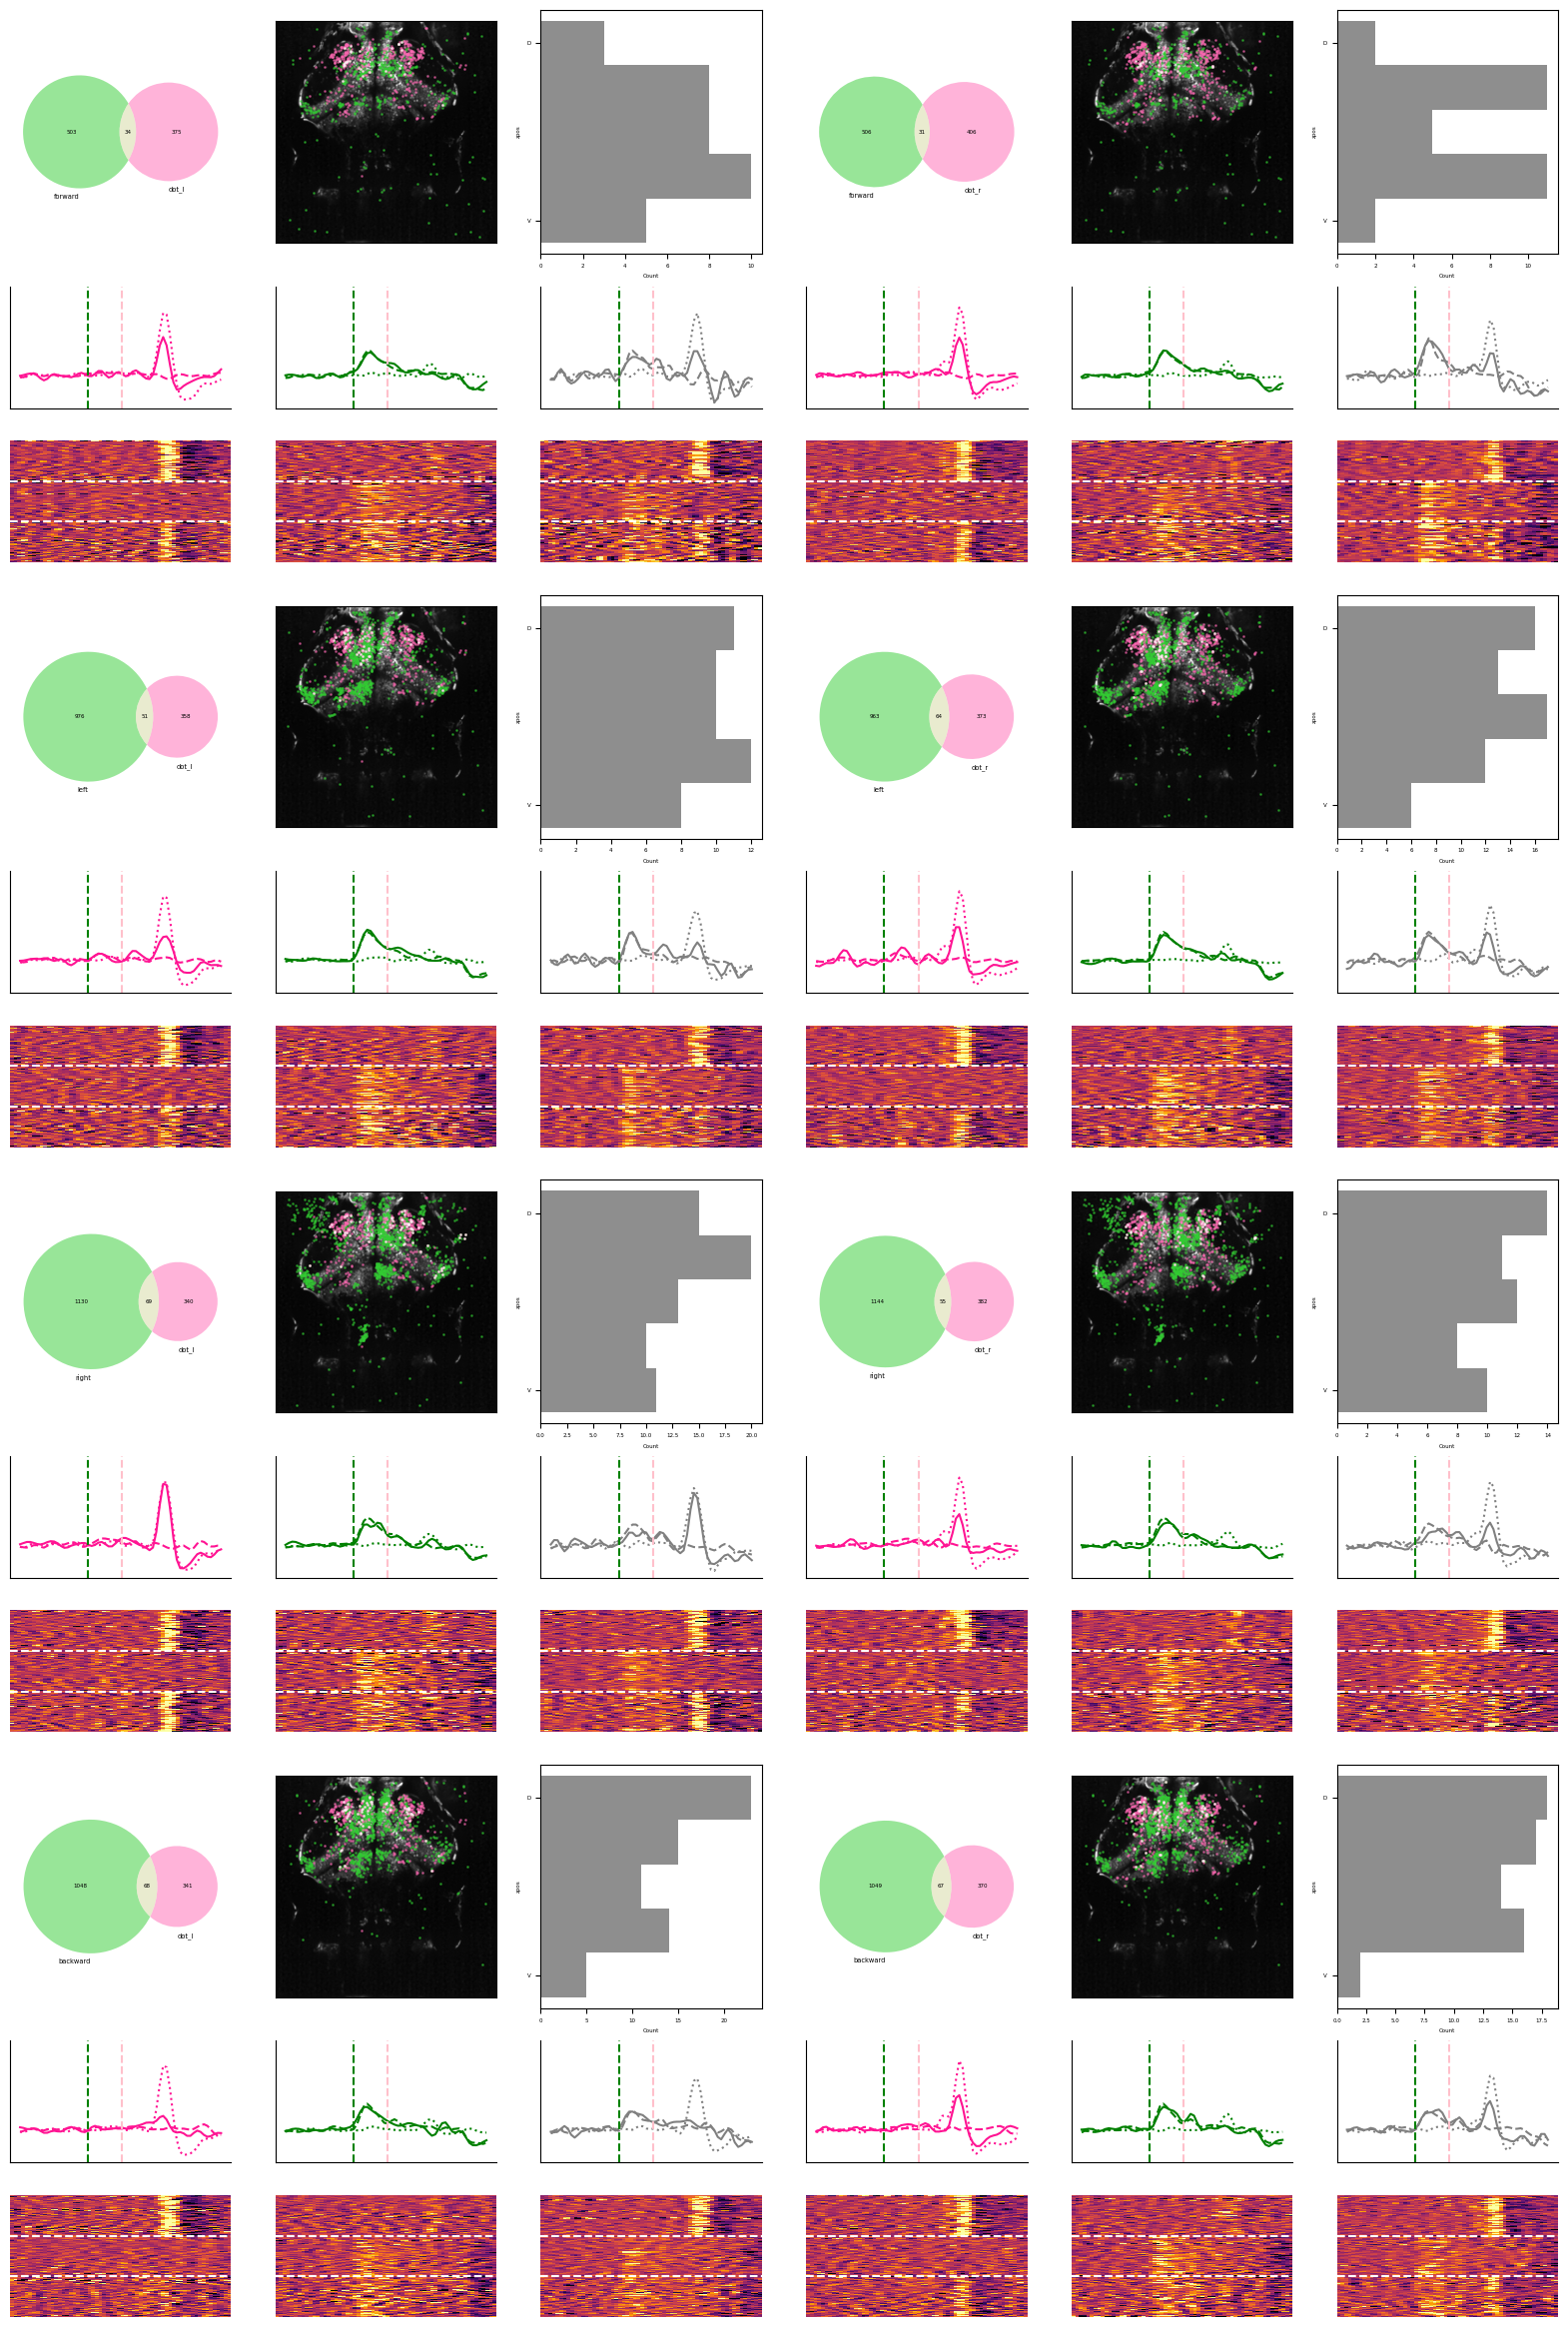

In [42]:
import itertools
from matplotlib_venn import venn2, venn3
def plot_shared_cells(fish, barred_gratingneurons, barred_dotneurons, barred_overlapneurons, baseline_s = 10, response_s = 20, stationary_s = 20):
    dot_stim = ['dot_l', 'dot_r']
    omr_stim = ['forward', 'left', 'right', 'backward']
    baseline_frame = int(baseline_s//fish.image_s)
    response_frame = int(response_s//fish.image_s)
    stationary_frame = int(stationary_s//fish.image_s)

    n_inpos = set(list(fish.pos_all[(fish.pos_all.ypos>0) & (fish.pos_all.ypos<5000)].index))

    fig, ax = plt.subplots(len(omr_stim) * 3, len(dot_stim) * 3, figsize = (20, 30), gridspec_kw={'height_ratios': [2, 1, 1] * len(omr_stim)})
    for i, (omr, dot) in enumerate(itertools.product(omr_stim, dot_stim)):#for each of the overlapping stimulus
        omr_set = set(barred_gratingneurons[omr])
        omr_set = (omr_set & n_inpos)
        dot_set = set(barred_dotneurons[dot])
        dot_set = (dot_set & n_inpos)
        dot_only = list(dot_set - omr_set)      # in dot, not in grating
        grating_only = list(omr_set - dot_set)      # in grating, not in dot
        overlap_true = set(barred_overlapneurons[str([dot, omr])])
        overlap_only = list(overlap_true - omr_set - dot_set)
        overlap = list(omr_set & dot_set)
        axrow = i//2 * 3
        axbigcol = i%2

        # --- (1) Venn diagram ---
        ax_venn = ax[axrow, axbigcol * 3]
        venn2([omr_set, dot_set], set_labels=(omr, dot), ax=ax_venn, set_colors=('limegreen', 'hotpink'),alpha=0.5)
        # venn3([omr_set, dot_set, overlap_true], set_labels=(omr, dot, str([dot, omr])), ax=ax_venn, set_colors=('limegreen', 'hotpink', 'grey'),alpha=0.5)

        # --- (2) Spatial map ---
        ax_img = ax[axrow, axbigcol * 3 + 1]
        ax_img.imshow(fish.img_dict[0], cmap='Greys_r', origin='lower', vmax=120)
        ax_img.scatter(fish.pos_all.loc[list(omr_set), 'xpos'], fish.pos_all.loc[list(omr_set), 'ypos'],
            s=1, facecolor='limegreen', label=omr, alpha=0.5)
        ax_img.scatter(fish.pos_all.loc[list(dot_set), 'xpos'], fish.pos_all.loc[list(dot_set), 'ypos'],
            s=1, facecolor='hotpink', label=dot, alpha=0.5)
        # highlight overlap neurons
        ax_img.scatter(fish.pos_all.loc[list(overlap), 'xpos'], fish.pos_all.loc[list(overlap), 'ypos'],
            s=1,  facecolor='white', label='overlap', alpha=.5)
        ax_img.grid(False)
        ax_img.set_xticks([])
        ax_img.set_yticks([])

        # --- (3) zpos ---
        ax_zpos = ax[axrow, axbigcol * 3 + 2]
        #only look at zpos
        sns.histplot(fish.pos_all.loc[overlap], y = 'zpos', bins = len(fish.planes), discrete=True, ax=ax_zpos, linewidth = 0, color = 'dimgrey')
        ax_zpos.invert_yaxis()
        ax_zpos.set_yticks([0, len(fish.planes) - 1])
        ax_zpos.set_yticklabels(['D', 'V'])

        # ___ (4) response___

        overlap_stim = str([dot, omr])
        clist = ['deeppink', 'green', 'grey']#colored according to neuron groups
        linelist = [':', '--', '-']
        for i, n in enumerate([dot_only, grating_only, list(overlap)]):
            ax_response = ax[axrow + 1, axbigcol * 3 + i]
            ax_heatmapresponse = ax[axrow + 2, axbigcol * 3 + i]
            f_collection = []
            for si, s in enumerate([dot, omr, overlap_stim]):
                trace_perneuron = np.diff(f_pertrial_dict[s][:, n, stationary_frame - baseline_frame:stationary_frame + response_frame].mean(axis = 0))
                f_collection.append(trace_perneuron)
                ax_response.plot(trace_perneuron.mean(axis = 0), c = clist[i], linestyle = linelist[si])
            sns.heatmap(np.concatenate(f_collection), ax = ax_heatmapresponse, xticklabels= [], yticklabels = [], vmin = -0.05, vmax = 0.05, cmap = 'inferno', cbar = False)
            ax_response.axvline(20//fish.image_s - stationary_frame + baseline_frame, linestyle = '--', color = 'green')
            ax_response.axvline(25//fish.image_s - stationary_frame + baseline_frame, linestyle = '--', color = 'pink')
            ax_response.set_ylim([-0.03, 0.08])
            ax_response.set_xticks([])
            ax_response.set_yticks([])
            ax_response.set_xticklabels([])
            ax_response.set_yticklabels([])
            ax_response.spines[['top', 'right']].set_visible(False)

            ax_heatmapresponse.axhline(f_collection[0].shape[0], linestyle = '--', color = 'white')
            ax_heatmapresponse.axhline(f_collection[0].shape[0] * 2, linestyle = '--', color = 'white')
    return fig
fig = plot_shared_cells(fish, barred_gratingneurons, barred_dotneurons, barred_overlapneurons)
plt.savefig(fish.path + '//Graphs//shared_stim.png')
plt.show()
plt.close()

In [62]:

import itertools
from matplotlib_venn import venn2, venn3


def shared_traces(barred_gratingneurons, barred_dotneurons, f_pertrial_dict):
    dot_stim = ['dot_l', 'dot_r']
    omr_stim = ['forward', 'left', 'right', 'backward']
    region_list = ['']
    f_collection = []
    neuron_identity_list = []
    stim_list = []
    for omr, dot in itertools.product(omr_stim, dot_stim):  #for each of the overlapping stimulus
        omr_set = set(barred_gratingneurons[omr])
        dot_set = set(barred_dotneurons[dot])
        overlap = omr_set & dot_set
        dot_only = list(dot_set - overlap)
        grating_only = list(omr_set - overlap)
        overlap_stim = str([dot, omr])
        for n, n_name in zip([dot_only, grating_only, list(overlap)], [f'{overlap_stim}_dotonly', f'{overlap_stim}_gratingonly', f'{overlap_stim}_both']):
            for s, s_name in zip([dot, omr, overlap_stim], ['dot', 'grating', 'overlap']):
                trace_perneuron = f_pertrial_dict[s][:, n].mean(axis=0)
                trace = trace_perneuron.mean(axis=0)
                f_collection.append(trace)
                neuron_identity_list.append(n_name)
                stim_list.append(s_name)
    f_collection = np.array(f_collection)
    f_collection = pd.DataFrame(f_collection)
    f_collection.loc[:, "neuron_identity"] = neuron_identity_list
    f_collection.loc[:, 'stim'] = stim_list
    return f_collection


f_collection = shared_traces(barred_gratingneurons, barred_dotneurons, f_pertrial_dict)
f_collection.to_csv(fish.path + '//analyze_results//multiplexed_trace.csv')

In [65]:
#combine across fish
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]
for path in paths:
    fish = Gafftopsail(path + '//', filelist=['stimulus', 'imaging'], sequence=5)
    fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]
    f_pertrial_dict = barcode.get_pertrial_f(fish)

    barred_dotneurons = pd.read_csv(fish.path + '//analyze_results//dot_responses.csv', index_col=0)
    barred_gratingneurons = pd.read_csv(fish.path + '//analyze_results//grating_responses_delayed.csv', index_col=0)
    #change them to dictionary
    dot_stims = ['dot_l', 'dot_r']
    grating_stims = ['forward', 'left', 'right', 'backward']
    barred_dotneurons = {s: list(barred_dotneurons[barred_dotneurons['barred_' + s]].index) for s in dot_stims}
    barred_gratingneurons = {s: list(barred_gratingneurons[barred_gratingneurons['barred_' + s]].index) for s in
                             grating_stims}

    f_collection = shared_traces(barred_gratingneurons, barred_dotneurons, f_pertrial_dict)
    f_collection.to_csv(fish.path + '//analyze_results//multiplexed_trace.csv')

low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getti

C:\Users\Zichen\AppData\Local\Temp\ipykernel_53636\785805786.py:22: RuntimeWarning: Mean of empty slice.
  trace = trace_perneuron.mean(axis=0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getti

C:\Users\Zichen\AppData\Local\Temp\ipykernel_53636\785805786.py:22: RuntimeWarning: Mean of empty slice.
  trace = trace_perneuron.mean(axis=0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getti

C:\Users\Zichen\AppData\Local\Temp\ipykernel_53636\785805786.py:22: RuntimeWarning: Mean of empty slice.
  trace = trace_perneuron.mean(axis=0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getti

C:\Users\Zichen\AppData\Local\Temp\ipykernel_53636\785805786.py:22: RuntimeWarning: Mean of empty slice.
  trace = trace_perneuron.mean(axis=0)
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
low passs assuming framerate ~2
smoothed
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s


__optional: example cell__

In [43]:
dot = 'dot_r'
omr = 'right'
omr_set = set(barred_gratingneurons[omr])
dot_set = set(barred_dotneurons[dot])
overlap = list(omr_set & dot_set)
overlap

[4992,
 7555,
 8324,
 5,
 5128,
 9353,
 652,
 6287,
 7055,
 7313,
 3090,
 4631,
 2456,
 410,
 9245,
 3359,
 3360,
 1574,
 3111,
 1453,
 5423,
 7346,
 2999,
 2745,
 571,
 708,
 9926,
 2507,
 7116,
 205,
 7117,
 463,
 592,
 720,
 216,
 4313,
 3931,
 95,
 4705,
 10722,
 9443,
 3046,
 487,
 4585,
 4713,
 6252,
 6640,
 10994,
 7027,
 9716,
 9590,
 4727,
 10872,
 5245,
 10111]

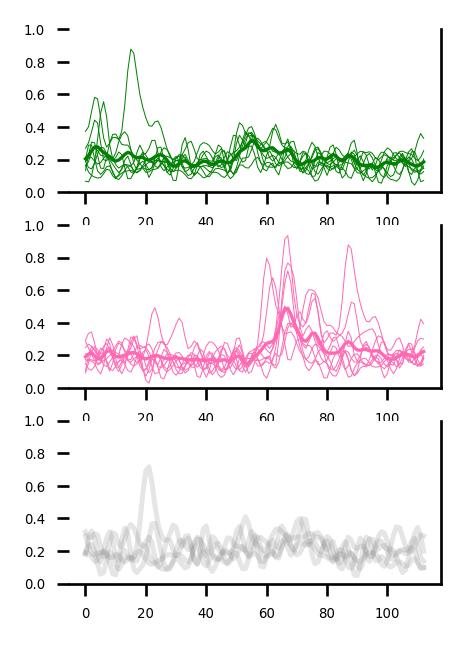

In [47]:
fig, ax = plt.subplots(3, 1, dpi = 240, figsize = (2, 3))
n =8324
for trial in range(0,9):
    ax[0].plot(f_pertrial_dict['right'][trial, n, :], c = 'green', alpha = 1, linewidth = .3)
    ax[1].plot(f_pertrial_dict['dot_r'][trial, n, :], c = 'hotpink', alpha = 1, linewidth = .3)
ax[0].plot(f_pertrial_dict['right'][:, n, :].mean(axis = 0), c = 'green', alpha = 1, linewidth = 1)
ax[1].plot(f_pertrial_dict['dot_r'][:, n, :].mean(axis = 0), c = 'hotpink', alpha = 1, linewidth = 1)
for trial in range(5):
    ax[2].plot(f_pertrial_dict[str(['dot_r', 'right'])][trial, n, :], c = 'grey', alpha = 0.2)
for axis in ax:
    axis.set_ylim([0, 1])
    axis.spines[['top', 'left']].set_visible(False)
#fig.savefig(r"C:\Users\Zichen\Desktop\deletelater//multiplex_example.svg")
plt.show()
plt.close()

In [25]:
plt.imshow(fish.img_dict[3], origin = 'lower')
plt.scatter(fish.pos_all.loc[n, 'xpos'], fish.pos_all.loc[n, 'ypos'])

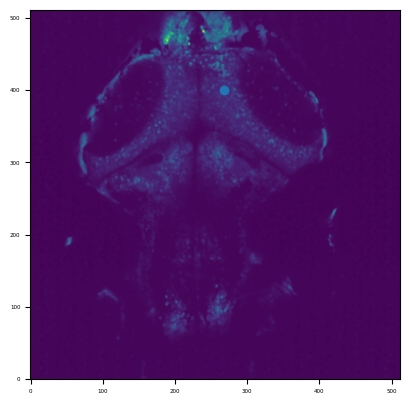

In [26]:
plt.show()
plt.close()